In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/employee-salary/employee_income.csv


https://www.kaggle.com/datasets/hiteshyadavx/employee-salary

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv('/kaggle/input/employee-salary/employee_income.csv')
df = pd.DataFrame(data)

# EDA

In [4]:
df.head()

,age,experience,income
0,50,5,45118
1,36,9,41691
2,29,3,35994
3,42,5,41614
4,40,12,51474


In [5]:
df.shape

(50, 3)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         50 non-null     int64
 1   experience  50 non-null     int64
 2   income      50 non-null     int64
dtypes: int64(3)
memory usage: 1.3 KB


In [7]:
df.describe()

,age,experience,income
count,50.000000,50.000000,50.000000
mean,38.860000,8.580000,44864.060000
std,10.719066,4.116121,6916.729587
min,23.000000,0.000000,28559.000000
25%,29.250000,6.250000,41039.250000
50%,39.500000,9.000000,46205.000000
75%,46.000000,12.000000,50064.000000
max,59.000000,14.000000,57092.000000


In [8]:
df.isnull().sum()

age           0
experience    0
income        0
dtype: int64

<Axes: xlabel='experience', ylabel='income'>

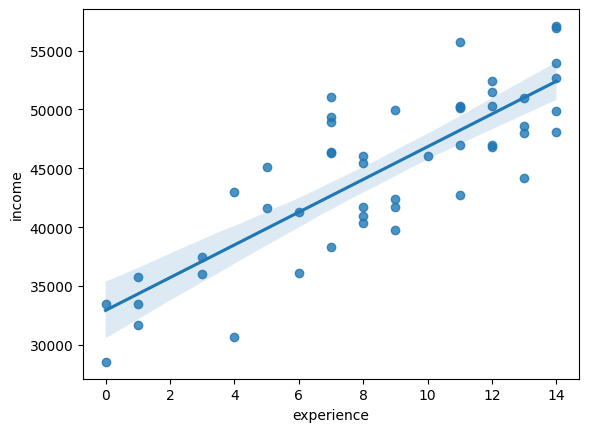

In [9]:
sns.regplot(data=df,x='experience',y='income')

# ML

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [11]:
X = df[['experience', 'age']] 
y = df[['income']] # output/predicter

In [12]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [13]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [14]:
model_prediction = model.predict(X_test)

In [15]:
# Checking Prediction accuracy
print("Using MSE : ", mean_squared_error(y_test,model_prediction))
r2 = r2_score(y_test,model_prediction)
print("Using R2 Score : ",r2)

Using MSE :  3061367.451388381
Using R2 Score :  0.9349274275513149


In [16]:
n = len(df) # Number of observations
p = X.shape[1] # Number of predictor variables
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"Adjusted R2: {adjusted_r2}")

Adjusted R2: 0.9321583819152006
